# COVID-19 time-series analysis

Jonathan Stickel, 2020

This purpose of this notebook (and repository) is to make available a set of time-series
analyses of COVID-19 data. Data sources are:

- https://github.com/CSSEGISandData/COVID-19 (COVID-19 data)
- https://covidtracking.com/ (COVID-19 US data)
- https://data.worldbank.org/indicator/sp.pop.totl (world populations)
- https://www.census.gov/data/tables/time-series/demo/popest/2010s-state-total.html (US populations)
- http://www.healthdata.org/ (hospital capacity)
- https://www.cdc.gov/ (total US deaths)

By default, the COVID-19 data is grabbed from web sources directly. See arguments to functions for specifying files in your local path.

To run the entire notebook, click `Cell` from the menu above and then `Run All`.

Dependencies are:

- `numpy`
- `pandas`
- `matplotlib`
- `cvxopt`
- `scikit.datasmooth` (can be pip installed)

Also, `covid19ts` and `covid_plots` are part of this repository.

Open this link in a new tab (right-click, "open link in new tab") for a web-based "live" notebook (it may take awhile to load, be patient):
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/jjstickel/covid-19_ts_analysis.git/master?filepath=analyze_covid_time_series_notebook.ipynb)


In [1]:
# import modules
import numpy as np
# locally defined modules
from covid19ts import covid19_global, covid19_ctp
import covid_plots as cvp

# User input

Put up to 7 countries of interest in the `countries` list. Must be the same name used in the J-H global files, and (at the moment), it must be a single entry in the file (e.g., China has multiple entries and will cause an Exception). At the moment, `US` must be in the list because it is included in all of the US plots.

In [2]:
countries = ["US", "Italy", "Spain", "Germany", "Sweden", "Brazil", "Mexico"]

Put up to 6 US states in the `US_locs` list. 

In [3]:
US_locs = ["Colorado", "California", "New York", "Florida", "Arizona", "South Dakota"]

Read in COVID-19 timeseries data for the locations specified and perform these operations:
- normalize cases to be per capita
- smooth the cases data
- set time-zero for each location and shift elapsed time in days
- determine rates (i.e., the derivative) for cases

In [4]:
# days before today to analyze; more days takes a little more processing time; use `None` to use all data
dbf = 200 
# global data
lmbd = 5e-5 # smoothing parameter, larger means more smooth
corona = covid19_global(countries, lmbd=lmbd, dbf=dbf)
# extract common variables for ease-of-use
mult = corona["mult"]
nctry = len(countries)
dates = corona["dates"]
lastday = dates[-1]
# US data
nUSloc = len(US_locs)
coronaUS_ctp = covid19_ctp(US_locs, lastday, lmbd=lmbd, dbf=dbf)

*Estimate* "active" cases by presuming all confirmed cases have recovered or died in an aeverage number of days. Estimate of recovery time from:
- https://www.thelancet.com/journals/laninf/article/PIIS1473-3099(20)30243-7/fulltext
- https://towardsdatascience.com/visual-notes-from-singapores-first-100-fully-recovered-covid-19-patients-aad7f2e1d0a0

Unfortunately, recovered data is really poor, and so directly calculating active cases is not useful.

In [5]:
rectime = 14 # days, 1 day = 1 data point -- you can change this number to see the affect on estimated active cases
for country in countries:
    ctryd = corona[country]
    ctryd["acvest_pc"] = ctryd["cnf_pc"].copy()
    ctryd["acvest_pc"][:rectime] = np.nan
    ctryd["acvest_pc"][rectime:] = ctryd["acvest_pc"][rectime:] - ctryd["cnf_pc"][:-rectime]
for loc in coronaUS_ctp["locs"]:
    locd = coronaUS_ctp[loc]
    locd["acvest_pc"] = locd["cnf_pc"].copy()
    locd["acvest_pc"][:rectime] = np.nan
    locd["acvest_pc"][rectime:] = locd["acvest_pc"][rectime:] - locd["cnf_pc"][:-rectime]

# Plotting

In [6]:
# plot setup
#reload(cvp)
cvp.rcParams.update({'font.size': 14})
cvp.fw = 8
cvp.fh = 6
#cvp.critlow_readable(corona) # provide convenient readable terms for time labeling

# Per capita cases (confirmed and deaths)

## Global

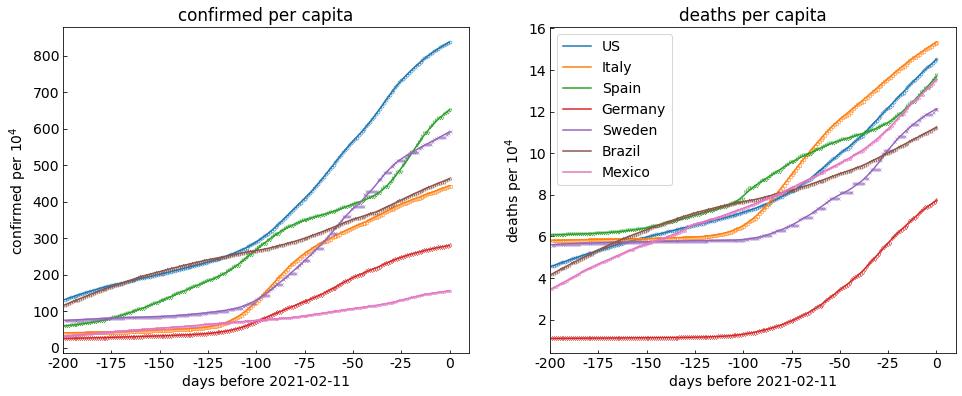

In [7]:
cvp.per_capita_global_plot(corona, lastday, days_before=dbf)

The US has a lot more confirmed per-capita cases than many countries now. This could be attributed to more testing at this point. Deaths continue to rise at a near linear pace. See rate plots below.

## US

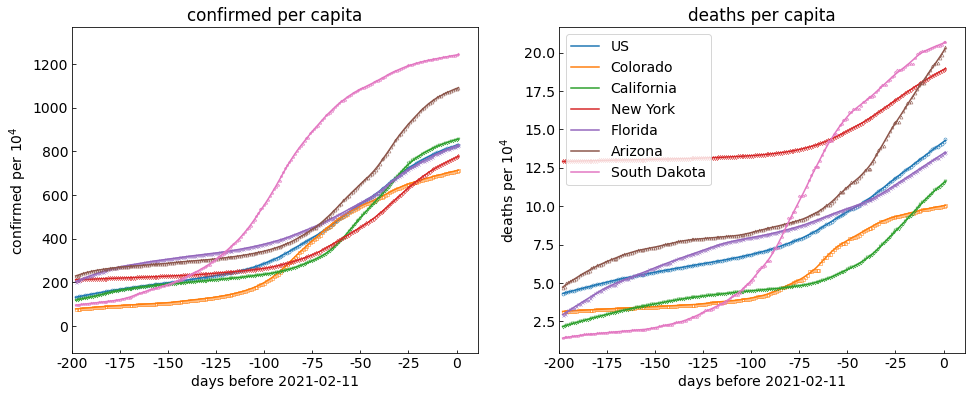

In [8]:
cvp.per_capita_US_plot(coronaUS_ctp, lastday, days_before=dbf)

US local per capita data. 

# Per capita growth rates (confirmed and deaths)

## Global

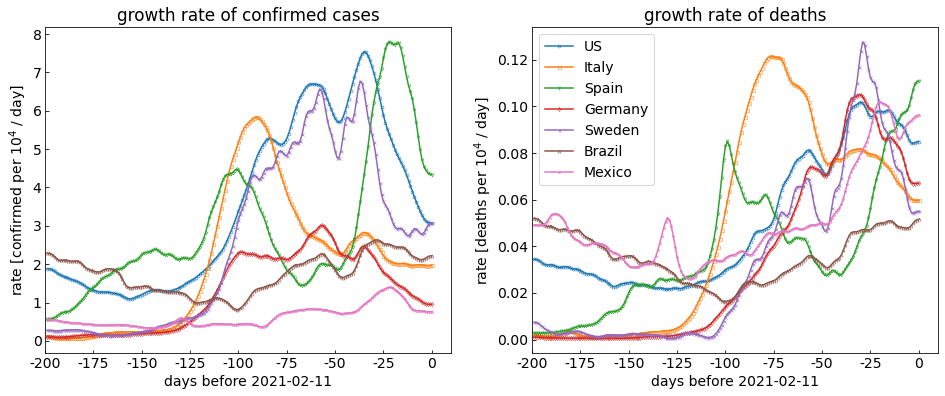

In [9]:
cvp.rate_global_plot(corona, lastday, days_before=dbf)

Growth rate is the derivative of the cases (i.e., instantaneous slope for each day). Rates have gone up and down over time. A flat rate means linear growth.

## US

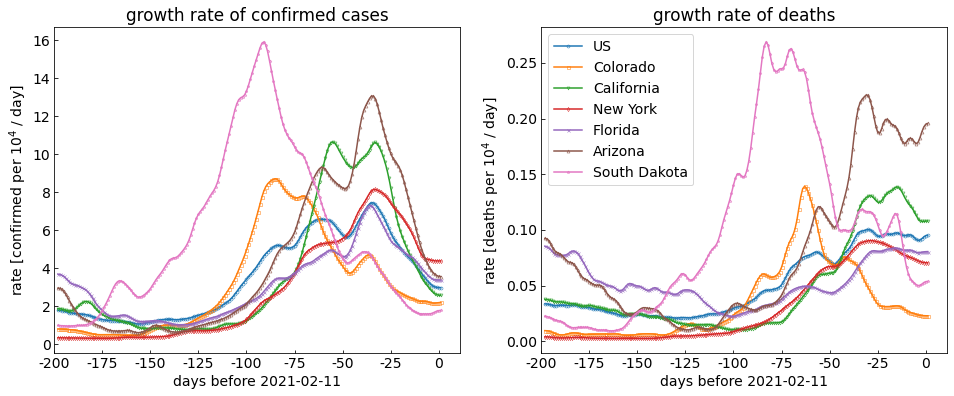

In [10]:
cvp.rate_US_plot(coronaUS_ctp, lastday, days_before=dbf)

US local rate data. 

# Active cases, hospitalizations, tests, and case fatality ratio (CFR)

## Global

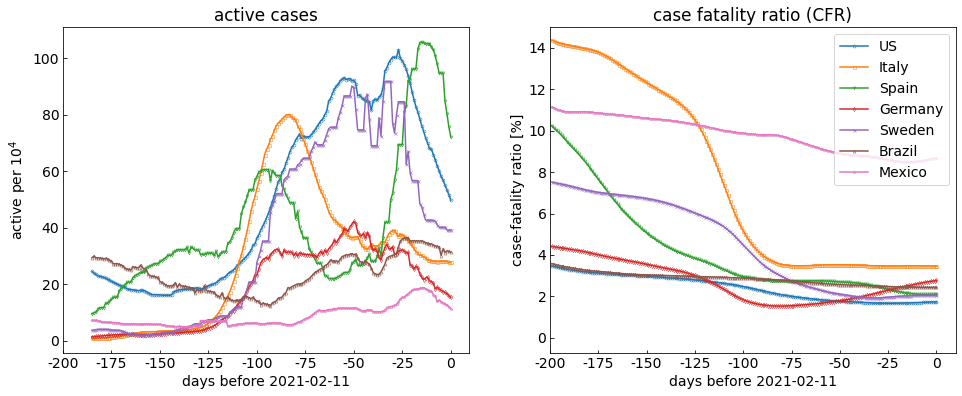

In [11]:
cvp.active_CFR_global_plot(corona, lastday, days_before=dbf)

Have we peaked? A curve of active cases help us answer this. While an initial peak ocurred months ago, we are now clearly having more waves.

The "case fatality ratio", or *CFR*, is an indication of how deadly a disease is. It is only an indication because it is limited by how many actual cases are measured and *confirmed*. Here, we see that the US is doing pretty good compared to other countries. Generally, more testing increases the denominator of the ratio and makes the CFR *lower*. (Note: the CFR is commonly called the case fatality *rate*. The use of the word rate here is technically incorrect---rate refers to something changing over *time*. [More info here](https://ourworldindata.org/coronavirus?fbclid=IwAR3zOvtt7gqkhitoHJ_lXDr3eDeE_JPtfukpOkY94PSaBm_hmrMvWCXWFpg#what-do-we-know-about-the-risk-of-dying-from-covid-19))

## US

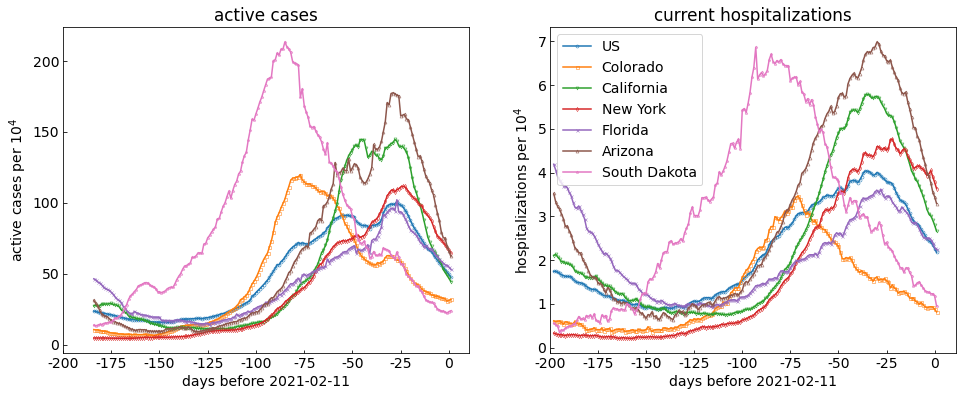

In [12]:
cvp.active_hosp_US_plot(coronaUS_ctp, lastday, days_before=dbf)

The Covid Tracking Project has data on hospitalizations by US state. I find it informative to plot hospitalizations next to active cases. Waves of hospitalizations follow closely active cases.

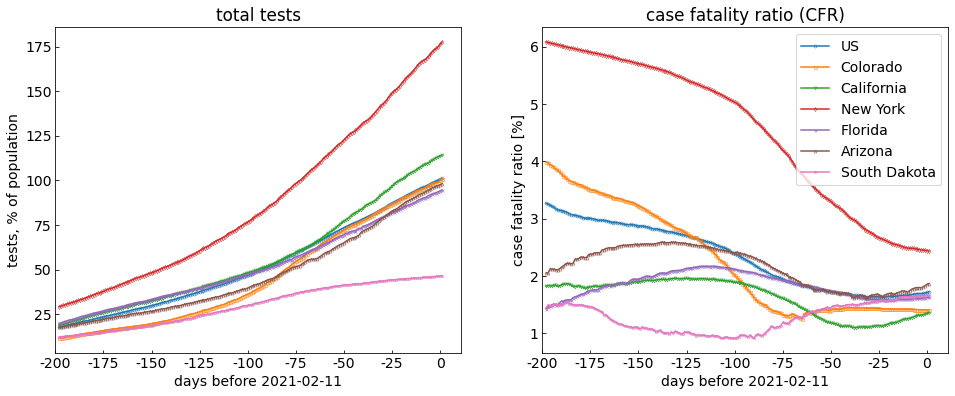

In [13]:
cvp.tests_CFR_US_plot(coronaUS_ctp, lastday, days_before=dbf)

US total tests and CFR. Testing has passed 100% of the population in NY (some people are getting multiple tests). As testing increases, so does the number of positive cases that are identified for people who are less likely to be hospitalized and die. This results in a lower CFR.

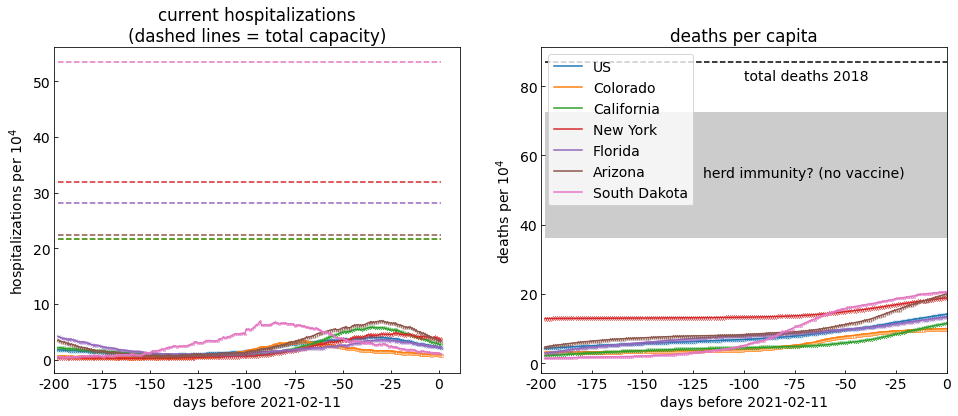

In [14]:
cvp.hosp_cap_deaths_US_plot(coronaUS_ctp, lastday, days_before=dbf)

How bad is COVID-19 really? Here are two figures to help put it in perspective. Hospitalizations are plotted with hospital capacity (left). There is still more hospital capacity, but COVID-19 patients are displacing those with other injuries and illnesses. 

Deaths are plotted with the total yearly US deaths in 2018 (right). We are approaching 20% of yearly deaths, and yearly deaths are less than 1% of the population in any given year, so COVID-19 mortality may be 0.2% of the population. Heard immunity, without a vaccine, could result in ~2-4 times this many deaths, or 0.5% of the population (this is calculated from the CDC's estimated IFR). While not trivial, it is nothing close to disasters of the pre-modern era. The Black Plague mortality is estimated to be about 50%, and famines during the middle ages resulted in 10-25% mortality, sometimes for several years in a row (Wikipedia).